# METR-LA traffic-speed forecasting with a multivariate temporal CNN–LSTM

This notebook uses 12 historical 5-minute observations to predict traffic speed
15, 30, and 60 minutes ahead (steps 3, 6, and 12).

The model applies one-dimensional temporal convolution over each historical input window to extract local temporal patterns, then uses an LSTM to model longer-term temporal dependencies. Measurements from multiple sensors are provided jointly as multivariate features, so cross-sensor relationships can be learned implicitly from the data.

This is not a graph-based spatial model: it does not use `adj_METR-LA.pkl`, an adjacency matrix, graph convolution, message passing, or an explicit representation of road-network topology. Consequently, it does not explicitly encode road-network structure or physical sensor connectivity; a graph-based model such as STGCN or DCRNN would be needed for topology-aware spatial modelling.

## Configuration

In [1]:
from pathlib import Path
import os
import random
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

DATA_PATH = Path(os.getenv("METR_LA_PATH", "datasets/METR-LA.h5"))
RESULTS_DIR = Path("results")
CHECKPOINT_PATH = RESULTS_DIR / "best_validation_checkpoint.pth"
TEST_METRICS_PATH = RESULTS_DIR / "test_metrics_by_horizon.csv"

# METR-LA releases may encode unavailable detector readings as zero. Confirm
# this convention for the dataset release in use before changing this setting.
TREAT_ZERO_AS_MISSING = True
MAPE_EPSILON = 1e-5
HISTORY_STEPS = 12
HORIZON_STEPS = (3, 6, 12)
SAMPLE_INTERVAL_MINUTES = 5
BATCH_SIZE = 64


def set_seed(seed: int = 42) -> None:
    """Set deterministic random seeds for reproducible training."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"METR-LA path: {DATA_PATH}")

# Optional Colab setup: set MOUNT_GOOGLE_DRIVE=true and METR_LA_PATH to a
# Drive path before running this cell. This notebook does not require Colab.
if os.getenv("MOUNT_GOOGLE_DRIVE", "").lower() == "true":
    try:
        from google.colab import drive
    except ModuleNotFoundError as error:
        raise RuntimeError("MOUNT_GOOGLE_DRIVE is only available in Colab.") from error
    drive.mount("/content/drive")


Using device: cpu
METR-LA path: datasets/METR-LA.h5


## Data loading

In [2]:
def validate_metr_la_frame(frame: pd.DataFrame) -> None:
    """Validate the index, columns, and numeric values of a METR-LA table."""
    if not isinstance(frame.index, pd.DatetimeIndex):
        raise TypeError("METR-LA data must have a DatetimeIndex of timestamps.")
    if frame.index.hasnans:
        raise ValueError("METR-LA timestamp index contains missing timestamps.")
    if not frame.index.is_monotonic_increasing:
        raise ValueError("METR-LA timestamps must be monotonic increasing.")
    if not frame.index.is_unique:
        raise ValueError("METR-LA timestamps must be unique.")
    if not frame.columns.is_unique:
        raise ValueError("METR-LA sensor columns must be unique.")
    non_numeric = [name for name in frame.columns if not pd.api.types.is_numeric_dtype(frame[name])]
    if non_numeric:
        raise TypeError(f"METR-LA sensor columns must be numeric; non-numeric: {non_numeric[:5]}")

    numeric_values = frame.to_numpy(dtype=float)
    print(f"Reported dataset shape: {frame.shape} (not hard-coded)")
    print(f"Timestamp range: {frame.index.min()} to {frame.index.max()}")
    print(f"Missing values: {int(frame.isna().to_numpy().sum())}")
    print(f"Zero values: {int((numeric_values == 0.0).sum())}")
    print(f"Non-finite values: {int((~np.isfinite(numeric_values)).sum())}")


def load_legacy_fixed_frame(file_path: Path) -> pd.DataFrame:
    """Read the legacy METR-LA fixed HDF5 layout when modern pandas cannot."""
    import tables

    with tables.open_file(file_path, mode="r") as h5_file:
        required_nodes = ("/df/axis0", "/df/axis1", "/df/block0_values")
        if not all(node in h5_file for node in required_nodes):
            raise ValueError("HDF5 file is not the expected legacy fixed-frame layout.")
        values = h5_file.get_node("/df/block0_values").read()
        raw_columns = h5_file.get_node("/df/axis0").read()
        raw_timestamps = h5_file.get_node("/df/axis1").read()

    columns = [value.decode() if isinstance(value, bytes) else str(value) for value in raw_columns]
    timestamps = pd.to_datetime(raw_timestamps, unit="ns")
    if values.ndim != 2 or values.shape != (len(timestamps), len(columns)):
        raise ValueError(
            "Legacy HDF5 values do not align with their timestamp and sensor axes: "
            f"values={values.shape}, timestamps={len(timestamps)}, sensors={len(columns)}."
        )
    return pd.DataFrame(values, index=timestamps, columns=columns)


def load_metr_la(file_path: Path) -> pd.DataFrame:
    """Load the real METR-LA HDF5 dataset; never substitute synthetic data."""
    if not file_path.is_file():
        raise FileNotFoundError(
            f"METR-LA dataset not found at {file_path}. "
            "Set DATA_PATH to the real METR-LA HDF5 file."
        )
    print(f"Loading METR-LA data from {file_path}...")
    try:
        frame = pd.read_hdf(file_path)
    except TypeError as error:
        print("Falling back to the legacy fixed-format HDF5 reader.")
        try:
            frame = load_legacy_fixed_frame(file_path)
        except Exception as fallback_error:
            raise RuntimeError("Unable to load the METR-LA HDF5 dataset.") from fallback_error
    validate_metr_la_frame(frame)
    return frame


df = load_metr_la(DATA_PATH)
NUM_SENSORS = df.shape[1]


Loading METR-LA data from datasets/METR-LA.h5...
Falling back to the legacy fixed-format HDF5 reader.
Reported dataset shape: (34272, 207) (not hard-coded)
Timestamp range: 2012-03-01 00:00:00 to 2012-06-27 23:55:00
Missing values: 0
Zero values: 575302
Non-finite values: 0


## Chronological splitting

In [3]:
def split_chronologically(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Return non-overlapping 70%/10%/20% chronological train/validation/test splits."""
    total_rows = len(frame)
    train_end = int(total_rows * 0.70)
    validation_end = int(total_rows * 0.80)
    train, validation, test = (
        frame.iloc[:train_end].copy(),
        frame.iloc[train_end:validation_end].copy(),
        frame.iloc[validation_end:].copy(),
    )
    assert len(train) + len(validation) + len(test) == total_rows
    assert train.index.max() < validation.index.min() < test.index.min()
    for name, split in (("Train", train), ("Validation", validation), ("Test", test)):
        print(f"{name}: {len(split)} rows ({len(split) / total_rows:.1%})")
    return train, validation, test


train_raw, val_raw, test_raw = split_chronologically(df)


Train: 23990 rows (70.0%)
Validation: 3427 rows (10.0%)
Test: 6855 rows (20.0%)


## Leakage-safe imputation

In [4]:
def mark_missing_values(frame: pd.DataFrame) -> pd.DataFrame:
    """Convert configured zero readings and non-finite numeric values to NaN."""
    prepared = frame.astype(float).copy()
    if TREAT_ZERO_AS_MISSING:
        prepared = prepared.mask(prepared == 0.0)
    return prepared.replace([np.inf, -np.inf], np.nan)


def impute_split(
    frame: pd.DataFrame, training_median: pd.Series, split_name: str
) -> pd.DataFrame:
    """Forward-fill one split, then use only training-derived per-sensor medians."""
    prepared = mark_missing_values(frame)
    values_to_impute = int(prepared.isna().to_numpy().sum())
    imputed = prepared.ffill().fillna(training_median)
    if imputed.isna().to_numpy().any() or not np.isfinite(imputed.to_numpy()).all():
        raise ValueError(f"{split_name} still has missing or non-finite values after imputation.")
    print(f"{split_name} values imputed: {values_to_impute}")
    return imputed


# The fallback statistics are fit from the training split only. Each split is
# forward-filled independently, so validation/test never read future values.
train_prepared = mark_missing_values(train_raw)
training_sensor_median = train_prepared.median(axis=0)
if training_sensor_median.isna().any():
    missing_sensors = training_sensor_median[training_sensor_median.isna()].index.tolist()
    raise ValueError(f"Cannot impute sensors with no finite training observations: {missing_sensors[:5]}")

train_df = impute_split(train_raw, training_sensor_median, "Train")
val_df = impute_split(val_raw, training_sensor_median, "Validation")
test_df = impute_split(test_raw, training_sensor_median, "Test")


Train values imputed: 354180
Validation values imputed: 49389
Test values imputed: 171733


## Training-only normalization

In [5]:
class StandardScaler:
    """A scalar z-score normalizer fit only on the cleaned training split."""

    def __init__(self) -> None:
        self.mean: float | None = None
        self.std: float | None = None

    def fit(self, frame: pd.DataFrame) -> "StandardScaler":
        values = frame.to_numpy(dtype=float)
        self.mean = float(values.mean())
        self.std = float(values.std())
        if not np.isfinite(self.std) or self.std == 0.0:
            raise ValueError("Training standard deviation must be finite and non-zero.")
        print(f"Scaler fit on training only — mean: {self.mean:.4f}, std: {self.std:.4f}")
        return self

    def transform(self, values: pd.DataFrame | np.ndarray) -> pd.DataFrame | np.ndarray:
        if self.mean is None or self.std is None:
            raise RuntimeError("Fit the scaler before transforming data.")
        return (values - self.mean) / self.std

    def inverse_transform(self, values: np.ndarray) -> np.ndarray:
        if self.mean is None or self.std is None:
            raise RuntimeError("Fit the scaler before inverse transforming data.")
        return (values * self.std) + self.mean


scaler = StandardScaler().fit(train_df)
train_scaled = scaler.transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)


Scaler fit on training only — mean: 58.4351, std: 13.0981


## Window generation

In [6]:
class TrafficDataset(data.Dataset):
    """Create CNN-ready input windows and 3/6/12-step targets from one split."""

    def __init__(
        self,
        data_array: np.ndarray,
        history_steps: int = HISTORY_STEPS,
        horizon_steps: Sequence[int] = HORIZON_STEPS,
    ) -> None:
        self.data = np.asarray(data_array, dtype=np.float32)
        self.history_steps = history_steps
        self.horizon_steps = tuple(horizon_steps)
        self.max_horizon = max(self.horizon_steps)
        valid_count = len(self.data) - self.history_steps - self.max_horizon + 1
        if valid_count <= 0:
            raise ValueError("Split is too short for the requested history and horizon.")
        self.valid_indices = np.arange(valid_count)

    def __len__(self) -> int:
        return len(self.valid_indices)

    def target_indices(self, start_idx: int) -> list[int]:
        return [start_idx + self.history_steps + step - 1 for step in self.horizon_steps]

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        start_idx = int(self.valid_indices[idx])
        x = self.data[start_idx : start_idx + self.history_steps].T
        y = self.data[self.target_indices(start_idx)]
        return torch.from_numpy(x), torch.from_numpy(y)


train_dataset = TrafficDataset(train_scaled.to_numpy())
val_dataset = TrafficDataset(val_scaled.to_numpy())
test_dataset = TrafficDataset(test_scaled.to_numpy())

# Alignment check: input indices 0–11 end at index 11; targets are 3, 6,
# and 12 five-minute steps later at indices 14, 17, and 23.
first_input_last_index = HISTORY_STEPS - 1
first_target_indices = train_dataset.target_indices(0)
assert first_target_indices == [14, 17, 23]
assert [index - first_input_last_index for index in first_target_indices] == list(HORIZON_STEPS)
assert [step * SAMPLE_INTERVAL_MINUTES for step in HORIZON_STEPS] == [15, 30, 60]
print(f"Alignment verified: input 0–{first_input_last_index}; targets {first_target_indices}")

train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Batches — train: {len(train_loader)}, validation: {len(val_loader)}, test: {len(test_loader)}")


Alignment verified: input 0–11; targets [14, 17, 23]
Batches — train: 375, validation: 54, test: 107


## Model training

In [7]:
class CNNLSTM(nn.Module):
    """Multivariate temporal CNN-LSTM with one output head per forecast horizon.

    Conv1d operates over the historical time axis; sensors are joint input
    channels rather than graph nodes.
    """

    def __init__(self, num_sensors: int, cnn_channels: int = 64, lstm_hidden: int = 128, lstm_layers: int = 2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(num_sensors, cnn_channels, kernel_size=3),
            nn.ReLU(),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.2 if lstm_layers > 1 else 0,
        )
        self.head_15m = nn.Linear(lstm_hidden, num_sensors)
        self.head_30m = nn.Linear(lstm_hidden, num_sensors)
        self.head_60m = nn.Linear(lstm_hidden, num_sensors)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cnn_output = self.cnn(x).permute(0, 2, 1)
        lstm_output, _ = self.lstm(cnn_output)
        last_hidden = lstm_output[:, -1, :]
        return torch.stack(
            [self.head_15m(last_hidden), self.head_30m(last_hidden), self.head_60m(last_hidden)],
            dim=1,
        )


model = CNNLSTM(num_sensors=NUM_SENSORS).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)


CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(207, 64, kernel_size=(3,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
    (3): ReLU()
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head_15m): Linear(in_features=128, out_features=207, bias=True)
  (head_30m): Linear(in_features=128, out_features=207, bias=True)
  (head_60m): Linear(in_features=128, out_features=207, bias=True)
)


In [8]:
def calculate_metrics_by_horizon(
    prediction: np.ndarray, target: np.ndarray, fitted_scaler: StandardScaler
) -> pd.DataFrame:
    """Return original-unit MAE, RMSE, and MAPE for each horizon and overall.

    MAPE excludes non-finite predictions/targets and targets with absolute
    magnitude below MAPE_EPSILON to avoid unstable division near zero.
    """
    prediction = np.asarray(prediction)
    target = np.asarray(target)
    expected_shape = (prediction.shape[0], len(HORIZON_STEPS), NUM_SENSORS)
    if prediction.ndim != 3 or target.ndim != 3 or prediction.shape != target.shape:
        raise ValueError("Prediction and target must have matching (samples, horizons, sensors) shapes.")
    if prediction.shape != expected_shape:
        raise ValueError(f"Expected shape (samples, {len(HORIZON_STEPS)}, {NUM_SENSORS}); got {prediction.shape}.")

    prediction = fitted_scaler.inverse_transform(prediction)
    target = fitted_scaler.inverse_transform(target)

    def metric_row(pred_values: np.ndarray, target_values: np.ndarray) -> dict[str, float | int]:
        finite_pair = np.isfinite(pred_values) & np.isfinite(target_values)
        if not finite_pair.any():
            return {"MAE": np.nan, "RMSE": np.nan, "MAPE (%)": np.nan, "Valid MAPE Count": 0}
        errors = pred_values[finite_pair] - target_values[finite_pair]
        mape_mask = finite_pair & (np.abs(target_values) >= MAPE_EPSILON)
        mape_values = np.abs(pred_values[mape_mask] - target_values[mape_mask]) / np.abs(target_values[mape_mask])
        return {
            "MAE": float(np.mean(np.abs(errors))),
            "RMSE": float(np.sqrt(np.mean(np.square(errors)))),
            "MAPE (%)": float(np.mean(mape_values) * 100) if mape_values.size else np.nan,
            "Valid MAPE Count": int(mape_values.size),
        }

    rows, labels = [], ["15 min", "30 min", "60 min"]
    for horizon_index, (label, step) in enumerate(zip(labels, HORIZON_STEPS)):
        rows.append({"Horizon Step": step, **metric_row(prediction[:, horizon_index], target[:, horizon_index])})
    rows.append({"Horizon Step": "All (3, 6, 12)", **metric_row(prediction, target)})
    metrics = pd.DataFrame(rows, index=[*labels, "Overall"])
    metrics.index.name = "Forecast Horizon"
    return metrics[["Horizon Step", "MAE", "RMSE", "MAPE (%)", "Valid MAPE Count"]]


class EarlyStopping:
    """Save the lowest-validation-loss checkpoint and stop after patience epochs."""

    def __init__(self, patience: int = 10, path: Path = CHECKPOINT_PATH) -> None:
        self.patience, self.path = patience, path
        self.counter, self.best_loss, self.early_stop = 0, np.inf, False

    def __call__(self, validation_loss: float, trained_model: nn.Module) -> None:
        if validation_loss < self.best_loss:
            print(f"Validation loss improved: {self.best_loss:.6f} -> {validation_loss:.6f}")
            torch.save(trained_model.state_dict(), self.path)
            self.best_loss, self.counter = validation_loss, 0
        else:
            self.counter += 1
            print(f"Early-stopping counter: {self.counter}/{self.patience}")
            self.early_stop = self.counter >= self.patience


def collect_predictions(
    trained_model: nn.Module, loader: data.DataLoader, loss_function: nn.Module
) -> tuple[float, np.ndarray, np.ndarray]:
    """Evaluate one loader without shuffling and collect scaled predictions/targets."""
    trained_model.eval()
    total_loss, predictions, targets = 0.0, [], []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = trained_model(batch_x)
            total_loss += loss_function(output, batch_y).item() * batch_x.size(0)
            predictions.append(output.cpu().numpy())
            targets.append(batch_y.cpu().numpy())
    if not predictions:
        raise ValueError("Evaluation loader produced no windows.")
    return total_loss / len(loader.dataset), np.concatenate(predictions), np.concatenate(targets)


def train_model(
    trained_model: nn.Module,
    training_loader: data.DataLoader,
    validation_loader: data.DataLoader,
    num_epochs: int = 5,
    patience: int = 10,
) -> tuple[nn.Module, list[float], list[float], pd.DataFrame]:
    """Train on train windows, select only by validation loss, then show validation horizons."""
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    early_stopping = EarlyStopping(patience=patience)
    train_losses, validation_losses = [], []
    for epoch in range(num_epochs):
        trained_model.train()
        total_train_loss = 0.0
        for batch_x, batch_y in training_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            output = trained_model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() * batch_x.size(0)
        train_loss = total_train_loss / len(training_loader.dataset)
        validation_loss, validation_predictions, validation_targets = collect_predictions(
            trained_model, validation_loader, criterion
        )
        validation_metrics = calculate_metrics_by_horizon(validation_predictions, validation_targets, scaler)
        overall = validation_metrics.loc["Overall"]
        train_losses.append(train_loss)
        validation_losses.append(validation_loss)
        print(
            f"Epoch [{epoch + 1}/{num_epochs}] | Train Loss: {train_loss:.4f} | "
            f"Val Loss: {validation_loss:.4f} | Val MAE: {overall['MAE']:.2f} | "
            f"Val RMSE: {overall['RMSE']:.2f} | Val MAPE: {overall['MAPE (%)']:.2f}%"
        )
        early_stopping(validation_loss, trained_model)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break

    trained_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    _, best_predictions, best_targets = collect_predictions(trained_model, validation_loader, criterion)
    best_validation_metrics = calculate_metrics_by_horizon(best_predictions, best_targets, scaler)
    print("\nBest-checkpoint validation metrics by horizon:")
    print(best_validation_metrics.to_string(float_format=lambda value: f"{value:.4f}"))
    return trained_model, train_losses, validation_losses, best_validation_metrics


In [9]:
print("Starting training...")
model, train_losses, val_losses, validation_metrics = train_model(
    model, train_loader, val_loader, num_epochs=50, patience=5
)


Starting training...
Epoch [1/50] | Train Loss: 0.3907 | Val Loss: 0.2997 | Val MAE: 4.00 | Val RMSE: 7.17 | Val MAPE: 11.78%
Validation loss improved: inf -> 0.299728
Epoch [2/50] | Train Loss: 0.2849 | Val Loss: 0.2774 | Val MAE: 3.87 | Val RMSE: 6.90 | Val MAPE: 11.12%
Validation loss improved: 0.299728 -> 0.277384
Epoch [3/50] | Train Loss: 0.2563 | Val Loss: 0.2709 | Val MAE: 3.77 | Val RMSE: 6.82 | Val MAPE: 10.80%
Validation loss improved: 0.277384 -> 0.270877
Epoch [4/50] | Train Loss: 0.2348 | Val Loss: 0.2600 | Val MAE: 3.70 | Val RMSE: 6.68 | Val MAPE: 10.41%
Validation loss improved: 0.270877 -> 0.260030
Epoch [5/50] | Train Loss: 0.2205 | Val Loss: 0.2597 | Val MAE: 3.72 | Val RMSE: 6.68 | Val MAPE: 10.31%
Validation loss improved: 0.260030 -> 0.259709
Epoch [6/50] | Train Loss: 0.2102 | Val Loss: 0.2598 | Val MAE: 3.72 | Val RMSE: 6.68 | Val MAPE: 10.38%
Early-stopping counter: 1/5
Epoch [7/50] | Train Loss: 0.2008 | Val Loss: 0.2608 | Val MAE: 3.70 | Val RMSE: 6.69 | Val

## Per-horizon evaluation

In [10]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

### Test metrics by horizon (original traffic-speed units)

In [11]:
# Model selection above used validation only. This is the single held-out test evaluation.
test_loss, all_test_preds, all_test_targets = collect_predictions(model, test_loader, criterion)
test_metrics = calculate_metrics_by_horizon(all_test_preds, all_test_targets, scaler)
print(f"Test Loss (MSE): {test_loss:.4f}")

test_metrics

Test Loss (MSE): 0.3254


,Horizon Step,MAE,RMSE,MAPE (%),Valid MAPE Count
Forecast Horizon,,,,,
15 min,3,4.091769,7.147857,11.620180,1414224
30 min,6,4.184273,7.391804,12.058144,1414224
60 min,12,4.424862,7.856581,13.043788,1414224
Overall,"All (3, 6, 12)",4.233635,7.471200,12.240704,4242672


In [12]:
test_metrics.to_csv(TEST_METRICS_PATH)
print(f"Saved test metrics to {TEST_METRICS_PATH}")

Saved test metrics to results/test_metrics_by_horizon.csv


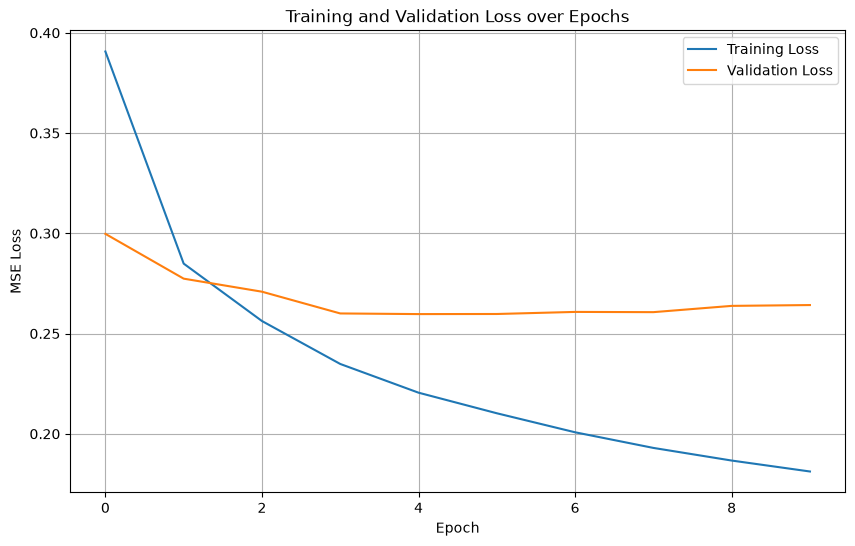

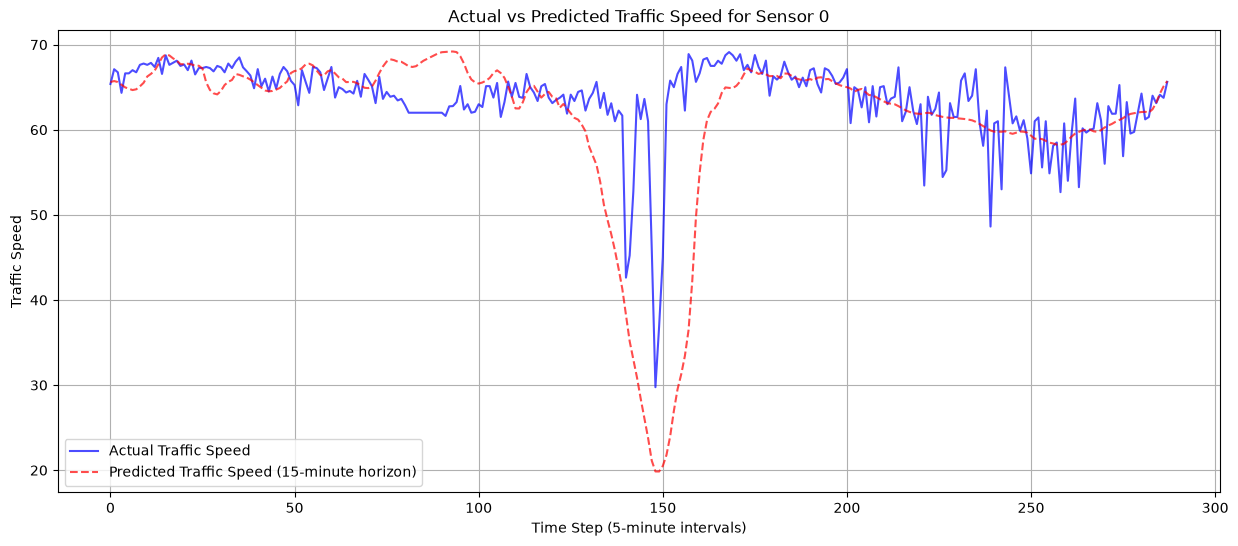

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

sensor_idx, horizon_idx, time_steps = 0, 0, 288
predictions_unscaled = scaler.inverse_transform(all_test_preds)
targets_unscaled = scaler.inverse_transform(all_test_targets)
actual_traffic = targets_unscaled[:time_steps, horizon_idx, sensor_idx]
predicted_traffic = predictions_unscaled[:time_steps, horizon_idx, sensor_idx]
plt.figure(figsize=(15, 6))
plt.plot(actual_traffic, label="Actual Traffic Speed", color="blue", alpha=0.7)
plt.plot(predicted_traffic, label="Predicted Traffic Speed (15-minute horizon)", color="red", alpha=0.7, linestyle="--")
plt.title(f"Actual vs Predicted Traffic Speed for Sensor {sensor_idx}")
plt.xlabel("Time Step (5-minute intervals)")
plt.ylabel("Traffic Speed")
plt.legend()
plt.grid(True)
plt.show()